# Sherrington-Kirkpatrick model

$\renewcommand{\ket}[1]{\left|#1\right\rangle}\renewcommand{\bra}[1]{\left\langle #1\right|}\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}\renewcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}$

This notebook shows how to generate instances of the Sherrington-Kirkpatrick model and reproduce the spectral-gap and classical-query calculations used in the paper. The notation follows the accompanying manuscript.

**Table of contents**

1. [Import](#import)
2. [Generation of the instances](#generation-of-the-instances)
3. [Average-case upper bounds on the coefficient 1-norm and operator norm](#average-case-upper-bounds)
4. [Best hyperparameters for the Hamiltonian-simulation proposal](#best-hyperparameters)
5. [Spectral-gap calculation](#spectral-gap-calculation)
6. [Spectral-gap plots](#spectral-gap-plots)
7. [Classical query calculation](#classical-query-calculation)
8. [Classical query plots](#classical-query-plots)

<a id="import"></a>
## Import

These are the modules used in the notebook. If `monaqa2` has not been installed, its path must be added to the locations searched by Python. From the `/notebooks` directory, the repository root is one level above.


In [1]:
import sys
if ".." not in sys.path:
    sys.path.append("..")  # Make the local package visible without an editable installation.

import matplotlib.pyplot as plt
import numpy as np

from monaqa2.data.classical_query import run_experiment_to_generate_classical_queries
from monaqa2.data.hyperparams import load_best_qemc_gamma_t, export_best_gamma_t_h5
from monaqa2.data.instances import load_instances
from monaqa2.data.plot_table import plot_spectral_gap_vs_beta, plot_spectral_gap_vs_n, plot_last_step_classical_queries_and_spectral_gap_vs_n
from monaqa2.data.spectral_gap import run_experiment_to_generate_spectral_gaps, load_spectral_gap
from monaqa2.mcmc.model import IsingModel, RandomIsingModel

<a id="generation-of-the-instances"></a>
## Generation of the instances

The instances of an $n$-spin SK model with fields are generated by:

1. sampling $n$ field terms from a Gaussian distribution with mean zero and variance one, $h_i \sim \mathcal{N}(0, 1)$;
2. sampling $\binom{n}{2}$ coupling terms from a Gaussian distribution with mean zero and variance one, $J_{ij} \sim \mathcal{N}(0, 1)$ for $i < j$;
3. determining the normalization factor
   $$\alpha=\sqrt{\frac{n}{\sum_i h_i^2+\sum_{i<j}J_{ij}^2}};$$
4. normalizing the coefficients as $\tilde{h}_i = \alpha h_i$ and $\tilde{J}_{ij} = \alpha J_{ij}$.

This normalization enforces $\sum_i \tilde{h}_i^2+\sum_{i<j}\tilde{J}_{ij}^2=n$ for every instance and gives the energy its standard extensive scaling. Alternatively, one may sample the normalized coefficients directly as $\tilde h_i,\tilde J_{ij}\sim \mathcal{N}(0,2/(n+1))$. In that case, the norm condition holds only on average: $\mathbb{E}[\|(\tilde h,\tilde J)\|_2^2]=n$.

Instances can be generated randomly using the `RandomIsingModel` class:


In [2]:
n = 3
random_model = RandomIsingModel(n=n, seed=1234)
print(f"Random model h=\n{random_model.h_rescaled}")
print(f"Random model J=\n{random_model.J_rescaled}")

Random model h=
[-0.25689444 -0.46925507  0.09598513]
Random model J=
[[0.         0.03506258 0.40526672]
 [0.03506258 0.         1.59346204]
 [0.40526672 1.59346204 0.        ]]


Alternatively, an instance can be created manually using the `IsingModel` class:


In [3]:
fixed_model = IsingModel.from_coefficients(
    n=n, 
    coefficients=np.hstack([random_model.h_rescaled, random_model.J_rescaled[np.triu_indices(n=n, k=1)]])
)
print(f"Fixed model h=\n{fixed_model.h_rescaled}")
print(f"Fixed model J=\n{fixed_model.J_rescaled}")

Fixed model h=
[-0.25689444 -0.46925507  0.09598513]
Fixed model J=
[[0.         0.03506258 0.40526672]
 [0.03506258 0.         1.59346204]
 [0.40526672 1.59346204 0.        ]]


The instances used in this work are the same as those used in [From quantum-enhanced to quantum-inspired Monte Carlo, Phys. Rev. A 111, 042615](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.111.042615), whose code is available at [https://github.com/petr-ivashkov/quantum-mcmc](https://github.com/petr-ivashkov/quantum-mcmc). They can be loaded using the following utilities.


In [4]:
n = 3  # Between 3 and 10, inclusive.
idx = 0  # Between 0 and 99, inclusive.
loaded_ising_model = load_instances(n, idx)
print(f"Loaded model h=\n{loaded_ising_model.h_rescaled}")
print(f"Loaded model J=\n{loaded_ising_model.J_rescaled}")

Loaded model h=
[-0.3958253  -1.23913116  0.7755628 ]
Loaded model J=
[[ 0.         -0.81979718  0.13006709]
 [-0.81979718  0.          0.13188543]
 [ 0.13006709  0.13188543  0.        ]]


The source of these instances is the `instances.json` file from [https://github.com/petr-ivashkov/quantum-mcmc](https://github.com/petr-ivashkov/quantum-mcmc). We processed the instances into the HDF5 file `data/ising_instances.hdf5` included in this repository.


<a id="average-case-upper-bounds"></a>
## Average-case upper bounds on the coefficient 1-norm and operator norm

Let $c=(h_1,\ldots,h_n,J_{12},\ldots,J_{n-1,n})\in\mathbb{R}^m$, with $m=n+\binom{n}{2}$, denote the vector of unnormalized Gaussian coefficients, where $c_i\sim\mathcal{N}(0,1)$. Let $\tilde c=\sqrt n\,c/\|c\|_2$ denote the corresponding normalized coefficient vector.

Since $c$ is a high-dimensional Gaussian vector, $\|c\|_1\simeq m\sqrt{2/\pi}$ and $\|c\|_2\simeq\sqrt m$. Therefore, the **typical coefficient 1-norm** of $\tilde c$ scales as

$$
\|\tilde c\|_1
=
\sqrt n\,\frac{\|c\|_1}{\|c\|_2}
\simeq
\sqrt n\,\frac{m\sqrt{2/\pi}}{\sqrt m}
=
\sqrt n\sqrt{\frac{2m}{\pi}}
=
n\sqrt{\frac{n+1}{\pi}}
\sim
\frac{1}{\sqrt\pi}n^{3/2}.
$$

We also find numerically that the **operator norm** of a typical instance scales approximately as $n$.

The following code validates these scalings:


In [5]:
def one_norm_ub(m):
    return np.abs(m.h_rescaled).sum() + np.abs(np.triu(m.J_rescaled, 1)).sum()

def op_norm_ub(m):
    return np.abs(m.energies_rescaled).max()

N_MODELS = 30
ns = np.array(range(5, 24 + 1))
models = [[RandomIsingModel(n, seed=N_MODELS * n + i) for i in range(N_MODELS)] for n in ns]
U1 = np.load("../data/sk_upper_bound_one_norm.npy")  # np.array([[one_norm_ub(m) for m in row] for row in models])
U2 = np.load("../data/sk_upper_bound_op_norm.npy")  # np.array([[op_norm_ub(m) for m in row] for row in models])

This produces the following plot:


In [6]:
plt.figure(figsize=(8, 4))
plt.errorbar(ns, U1.mean(1), yerr=U1.std(1), fmt="o", capsize=3, label="Empirical coefficient 1-norm")
plt.errorbar(ns, U2.mean(1), yerr=U2.std(1), fmt="o", capsize=3, label="Empirical operator norm")
plt.plot(ns, ns**1.5 / np.sqrt(np.pi), "--", label=r"Expected coefficient 1-norm: $n^{3/2}/\sqrt{\pi}$")
plt.plot(ns, ns, "--", label=r"Expected operator norm: $n$")
plt.title("Empirical and expected norm scalings")
plt.xlabel(r"$n$")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("plots/1_sk_upper_bounds.png", dpi=300, bbox_inches="tight")
plt.close()

![plots/1_sk_upper_bounds.png](plots/1_sk_upper_bounds.png)


<a id="best-hyperparameters"></a>
## Best hyperparameters for the Hamiltonian-simulation proposal

The repository [https://github.com/petr-ivashkov/quantum-mcmc](https://github.com/petr-ivashkov/quantum-mcmc) performed a grid search over the transverse-field strength $\gamma$ and evolution time $t$ for the Hamiltonian-simulation proposal used in quantum-enhanced Monte Carlo. The optimized pairs $(\gamma,t)$ are stored in that repository under `data/grid_search_n<n>[_fine].json` for $n\leq 10$.

The function `monaqa2.data.hyperparams.export_best_gamma_t_h5` processes these JSON files and generates `data/best_hyperparams_qemc.hdf5`, which is included in this repository. The code retains the internal label `qemc` for compatibility with the source data, while the paper refers to this proposal as the Hamiltonian-simulation move. No additional hyperparameter optimization is therefore required for the pre-generated instances.

The hyperparameters can be loaded using:


In [7]:
n = 3  # Between 3 and 10, inclusive.
idx = 0  # Between 0 and 99, inclusive.
load_best_qemc_gamma_t(n, idx)

(0.4631578947368421, 17.23404255319149)

<a id="spectral-gap-calculation"></a>
## Spectral-gap calculation

For each pre-generated instance, proposal rule, and inverse temperature $\beta$, we compute the absolute spectral gap $\delta_\beta$ of the corresponding transition matrix $P_\beta$.

Determining the spectral gap

$$
\delta_\beta
=
1-
\max\left\{
|\lambda|:\lambda\in\operatorname{spec}(P_\beta),\ |\lambda|<1
\right\}
$$

requires an eigendecomposition. For a reversible chain, the discriminant matrix $X$, with entries $X_{yx}=\sqrt{(P_\beta)_{yx}(P_\beta)_{xy}}$, is similar to $P_\beta$ and therefore has the same spectrum. Since $X$ is symmetric, its eigenvalues can be computed using `numpy.linalg.eigvalsh`.

The code below computes the spectral gaps:

* for all system sizes $n=3,\ldots,10$ and instance indices $\mathrm{idx}=0,\ldots,99$;
* for all inverse temperatures
  $$
  \beta\in\{0.01,0.02,\ldots,0.10,0.20,0.30,\ldots,1.00,2,3,\ldots,10,20,30,\ldots,100\};
  $$
* for all proposal labels available in the dataset: `uniform`, `local1`, `local2`, `local3`, `qemc`, and `layden`;
* for the Metropolis-Hastings acceptance rule, represented internally by $a=\infty$. Partial results are also available for the Glauber rule, $a=1$, and the generalized Glauber rule with exponent $10$, $a=10$.


To reproduce the spectral-gap calculations, run the following command. **Warning: the calculation is computationally expensive.**


In [8]:
# run_experiment_to_generate_spectral_gaps()

The results are stored in pandas pickle format at `data/spectral_gaps_merged.pkl`. The module `monaqa2.data.spectral_gap` provides the function `load_spectral_gap(proposal, a)`, which returns a pandas `DataFrame` containing the precomputed results for all system sizes $n$, instance indices, and inverse temperatures $\beta$ for a fixed proposal and acceptance rule.

The proposal label can be `uniform`, `local1`, `local2`, `local3`, `qemc`, or `layden`. The acceptance parameter can be $a=\infty$, $a=1$, or $a=10$. Only the results for $a=\infty$, corresponding to the Metropolis-Hastings rule used in the paper, are complete. The example below illustrates the loader for $a=1$.


In [9]:
load_spectral_gap("uniform", a=1).head()

,n,idx,beta,delta
0,3,0,0.01,0.49454
1,3,0,0.02,0.489084
2,3,0,0.03,0.483637
3,3,0,0.04,0.478204
4,3,0,0.05,0.472788


<a id="spectral-gap-plots"></a>
## Spectral-gap plots

We can plot the spectral gap $\delta_\beta$ as a function of the inverse temperature $\beta$ for fixed $n\in\{3,\ldots,10\}$.

At high temperature, $\beta\leq0.1$, the uniform move is the best classical baseline because almost all long-range proposals are accepted. Around $\beta=1$, the local move performs better on average. At lower temperatures, $\beta\geq4$, locality becomes a bottleneck and the uniform move again becomes the best classical proposal. The Hamiltonian-simulation move improves on the best classical proposal above the critical regime.

These plots are consistent with the evidence presented for dense Ising models in [*Quantum-enhanced Markov chain Monte Carlo*](https://www.nature.com/articles/s41586-023-06095-4); see [Supplementary Figs. S2 and S3 and Supplementary Table S1](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-023-06095-4/MediaObjects/41586_2023_6095_MOESM1_ESM.pdf).


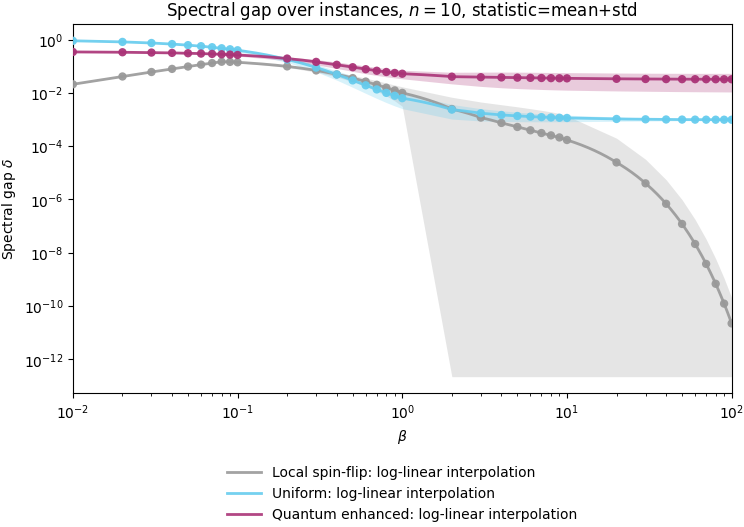

In [10]:
fig, ax = plot_spectral_gap_vs_beta(fixed_n=10)

The scaling of the spectral gap with system size at fixed inverse temperature is shown below.

The low-temperature regime, which is the most promising for a quantum speedup, makes the local spin-flip move difficult to fit reliably. We expect the local move to perform worse than the uniform move both in its measured spectral gap and in its asymptotic scaling. The first statement is clear from the data, while the second is obscured by numerical precision. For $n=10$, and sometimes also for $n=9$, the spectral gap of the local move falls below machine precision for the hardest instances. These unresolved values are removed from the statistics. Consequently, the uniform and Hamiltonian-simulation averages include all 100 instances for each $n$, whereas the local average includes only the numerically resolvable subset. This selection effect creates an artificial plateau and biases the fitted scaling upward, although the expected decay remains compatible with the broad standard-deviation bands.


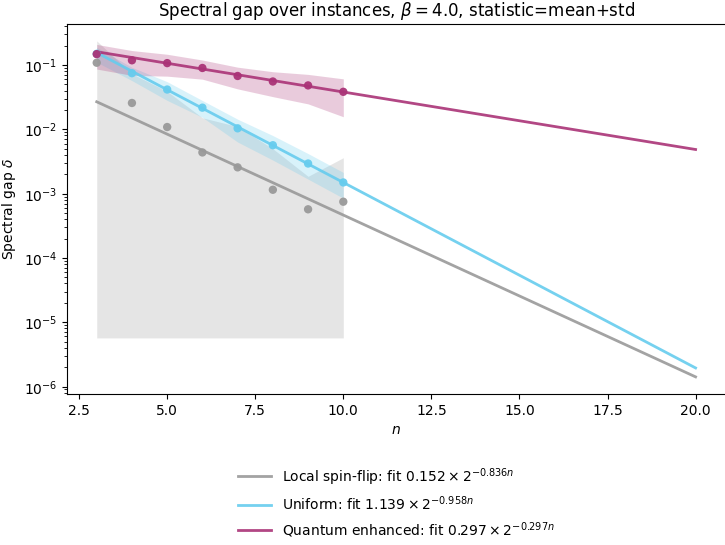

In [11]:
fig, ax = plot_spectral_gap_vs_n(fixed_beta=4.0, n_plot_min=3, n_plot_max=20, statistic="mean+std")

To mitigate this artifact, we can use more robust statistics. The option `mean+std-tail` computes the mean and standard deviation over the central quartiles, while `median+mad` computes the median and median absolute deviation. These statistics characterize a typical instance rather than the arithmetic average over the complete instance distribution. They are less sensitive to unresolved hard instances and recover the expected behavior more reliably.


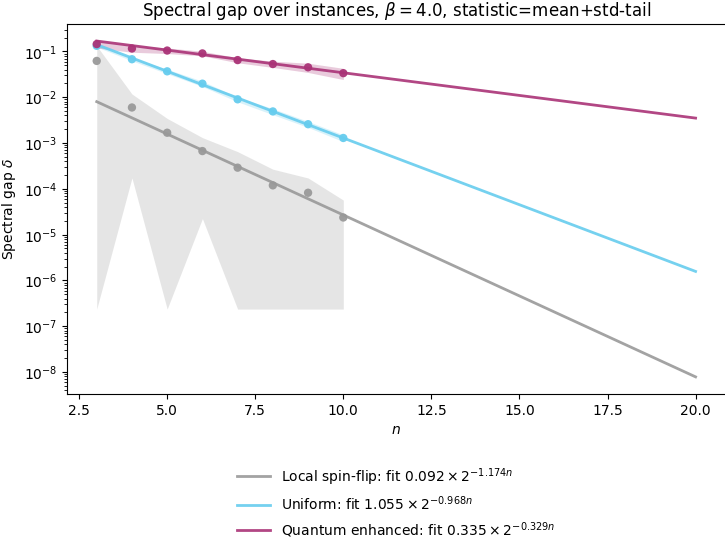

In [12]:
fig, ax = plot_spectral_gap_vs_n(fixed_beta=4.0, n_plot_min=3, n_plot_max=20, statistic="mean+std-tail")

In the paper, we report only the best classical and quantum approaches. In the low-temperature regime, the uniform move is the best classical baseline.


<a id="classical-query-calculation"></a>
## Classical query calculation

For each transition matrix $P_\beta$, we define the number of moves required by classical MCMC, referred to as the *classical query count*, as the first Markov-chain time $t$ at which the distribution evolved from $q_0$ is within total-variation distance $\varepsilon$ of the target Gibbs distribution $\pi_\beta$.

For reversible chains, rather than evolving $q_t$ directly, we usually evolve the normalized deviation $g_t=(q_t-\pi_\beta)/\sqrt{\pi_\beta}$ in the eigenbasis of the symmetric discriminant matrix $X$. This gives a stable spectral representation whenever $\min_x\pi_\beta(x)$ exceeds the spectral tolerance $10^{-8}$. When some entries of $\pi_\beta$ are too small, division by $\sqrt{\pi_\beta}$ becomes ill-conditioned, so we instead compute the direct evolution $q_t=P_\beta^tq_0$.

The classical query count primarily tracks the inverse spectral gap, while the initial distribution contributes through a smaller logarithmic factor. For the later comparison, we require a warm start. Instead of always starting from the uniform distribution, we also use an initial Gibbs distribution at a higher temperature, chosen so that its squared Bhattacharyya overlap with the target distribution is at least $1/e$. This is the setting used in simulated annealing, where each intermediate Gibbs distribution provides a warm start for the next step.

The code below computes the classical query count:

* for all system sizes $n=3,\ldots,10$ and instance indices $\mathrm{idx}=0,\ldots,99$;
* for all inverse temperatures
  $$
  \beta\in\{0.01,0.02,\ldots,0.10,0.20,0.30,\ldots,1.00,2,3,\ldots,10,20,30,\ldots,100\};
  $$
* for all total-variation tolerances $\varepsilon\in\{10^{-2},10^{-3},\ldots,10^{-8}\}$;
* for all proposal labels available in the dataset: `uniform`, `local1`, `local2`, `local3`, `qemc`, and `layden`;
* for the Metropolis-Hastings acceptance rule, represented internally by $a=\infty$. Partial results are also available for $a=1$ and $a=10$;
* for the initialization modes `uniform` and `bhattacharyya`. In the first case, $q_0$ is the uniform distribution, corresponding to $\beta_0=0$. In the second case, $q_0=\pi_{\beta_0}$, where $\beta_0\leq\beta$ is chosen so that
  $$
  \left(\sum_x\sqrt{\pi_{\beta_0}(x)\pi_\beta(x)}\right)^2\geq\frac{1}{e}.
  $$

Run the following command to reproduce the calculation. **Warning: the calculation is computationally expensive.**


In [13]:
# run_experiment_to_generate_classical_queries(n_list=[3, 4, 5])

<a id="classical-query-plots"></a>
## Classical query plots

These plots show how the warm-start classical query count scales with $n$ in the low-temperature regime.

Specifically, they show the number of classical queries required to reach the target Gibbs distribution within total-variation distance $\varepsilon$, starting from a distribution satisfying the warm-start condition. The inverse spectral gap can optionally be displayed on the right-hand $y$-axis. The classical query count and inverse spectral gap are expected to have comparable scaling, up to the contribution of the initial distribution.

The inverse spectral gap characterizes the slowest possible convergence mode. In practice, the initial distribution is a linear combination of fast and slow modes. Although slow modes require more time to decay, the projection onto the slowest mode can be sufficiently small that it has little effect at moderate accuracy. Consequently, the observed query scaling need not be determined exactly by the inverse spectral gap. As $\varepsilon\to0$, however, even small projections become increasingly relevant.

In these plots, the inverse spectral gap and classical query count have comparable scaling. The local move is again an exception because its numerical spread is too large to obtain a reliable fit, as indicated by the large fitted prefactor. This does not affect the comparison because the local move is not the best classical baseline in this regime.


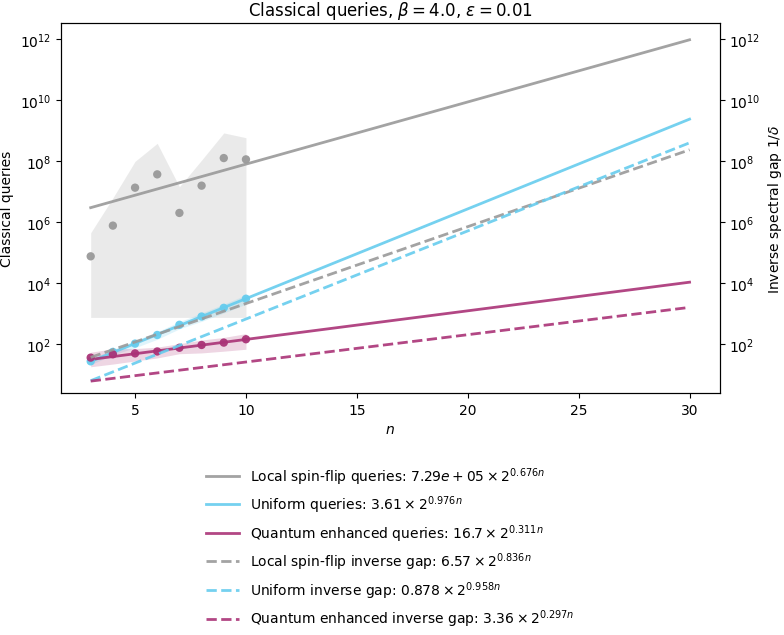

In [14]:
fig, ax, ax_gap = plot_last_step_classical_queries_and_spectral_gap_vs_n(beta=4.0, epsilon=1e-2, show_inverse_gap=True, n_plot_min=3, n_plot_max=30)

Other statistics can also be selected.
